# Лабораторная работа 6. Модели линейной регрессии

### Задание 2. Исследование линейной, гребневой и лассо регрессии


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")
%matplotlib inline

sns.set(style="darkgrid")

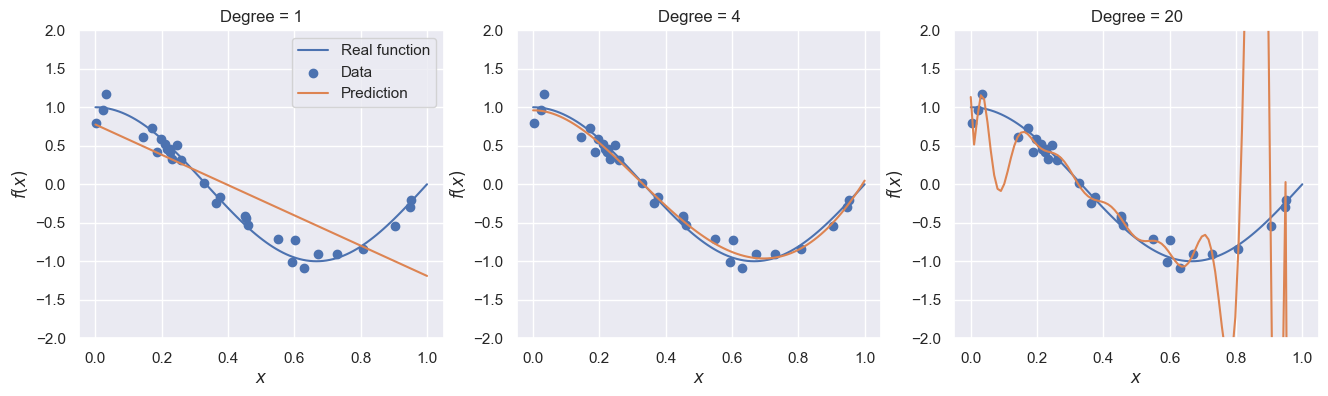

In [3]:
## Введение в линейные модели
from sklearn.linear_model import LinearRegression

np.random.seed(36)
x = np.linspace(0, 1, 100)
y = np.cos(1.5 * np.pi * x)

x_objects = np.random.uniform(0, 1, size=30)
y_objects = np.cos(1.5 * np.pi * x_objects) + np.random.normal(scale=0.1, size=x_objects.shape)

from sklearn.preprocessing import PolynomialFeatures
fig, axs = plt.subplots(figsize=(16, 4), ncols=3)
for i, degree in enumerate([1, 4, 20]):
    X_objects = PolynomialFeatures(degree, include_bias=False).fit_transform(x_objects[:, None])
    X = PolynomialFeatures(degree, include_bias=False).fit_transform(x[:, None])
    regr = LinearRegression().fit(X_objects, y_objects)
    y_pred = regr.predict(X)
    axs[i].plot(x, y, label="Real function")
    axs[i].scatter(x_objects, y_objects, label="Data")
    axs[i].plot(x, y_pred, label="Prediction")
    if i == 0:
        axs[i].legend()
    axs[i].set_title("Degree = %d" % degree)
    axs[i].set_xlabel("$x$")
    axs[i].set_ylabel("$f(x)$")
    axs[i].set_ylim(-2, 2)
plt.show()

### Ответ на вопрос 1:
Первая модель (degree=1) получилась плохой, потому что она слишком простая и не может описать сложную нелинейную зависимость cos(1.5πx). Третья модель (degree=20) переобучилась, потому что она слишком сложная и подстроилась под шум в данных, а не под истинную закономерность.

### Ответ на вопрос 2:
Большие веса в линейной модели плохи, потому что:

Модель становится слишком чувствительной к небольшим изменениям входных данных

Повышается риск переобучения

Модель теряет обобщающую способность

### Ответ на вопрос 3:
Регуляризовать w₀ - плохая идея, потому что:

w₀ (свободный член) отвечает за смещение модели и не связан с конкретными признаками

Регуляризация w₀ может сместить всю модель без улучшения обобщающей способности

Это не влияет на сложность модели, а только изменяет ее положение в пространстве

### Ответ на вопрос 4:
Коэффициент λ влияет на силу регуляризации:

При уменьшении λ модель становится ближе к обычной линейной регрессии (возрастает риск переобучения)

При увеличении λ модель становится более простой (возрастает риск недообучения)

Слишком большой λ приведет к тому, что все веса станут близки к нулю (модель будет предсказывать константу)

### Часть 1

In [4]:
# Загрузка данных
import requests
import io

url = 'https://www.dropbox.com/s/6dxq90t0prn2vaw/_train_sem2.csv?dl=1'
response = requests.get(url)
data = pd.read_csv(io.StringIO(response.text))

print("Размер данных:", data.shape)
print("Первые 5 строк:")
data.head()

Размер данных: (1460, 81)
Первые 5 строк:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
from sklearn.model_selection import train_test_split

data = data.drop(columns=["Id"])
y = data["SalePrice"]
X = data.drop(columns=["SalePrice"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

print(f"Обучающая выборка: {X_train.shape[0]} примеров")
print(f"Тестовая выборка: {X_test.shape[0]} примеров")

Обучающая выборка: 1022 примеров
Тестовая выборка: 438 примеров


### Ответ на вопрос 1:
Поля типа id могут вызвать переобучение, потому что модель может запомнить соответствие между id и целевой переменной вместо выявления реальных закономерностей.

### Ответ на вопрос 2:
Валидационную выборку стоит отделять для:

Подбора гиперпараметров модели

Оценки качества модели на данных, которые не участвовали в обучении

Предотвращения переобучения при настройке параметров

### Ответ на вопрос 3:
Фиксация random_state важна для воспроизводимости результатов. Без этого при каждом запуске данные будут делиться по-разному, что затруднит сравнение моделей.

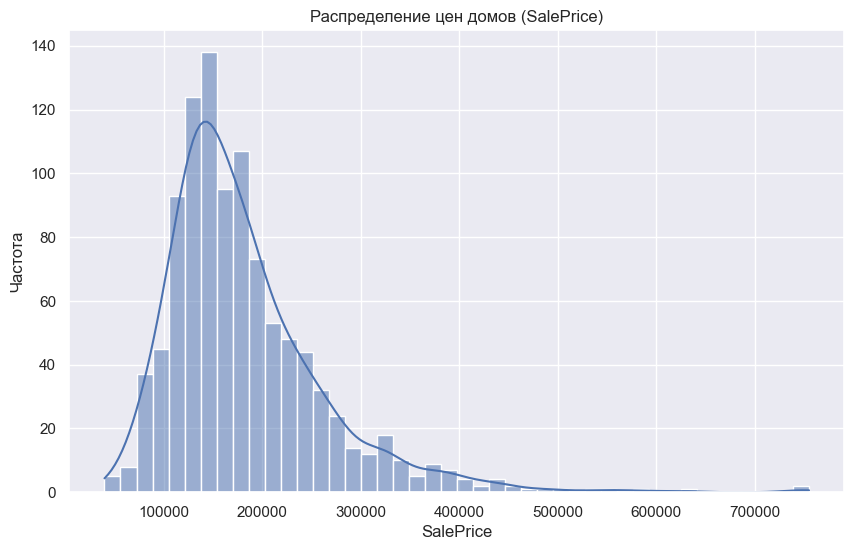

In [13]:
# Анализ целевой переменной
plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True)
plt.title('Распределение цен домов (SalePrice)')
plt.xlabel('SalePrice')
plt.ylabel('Частота')
plt.show()

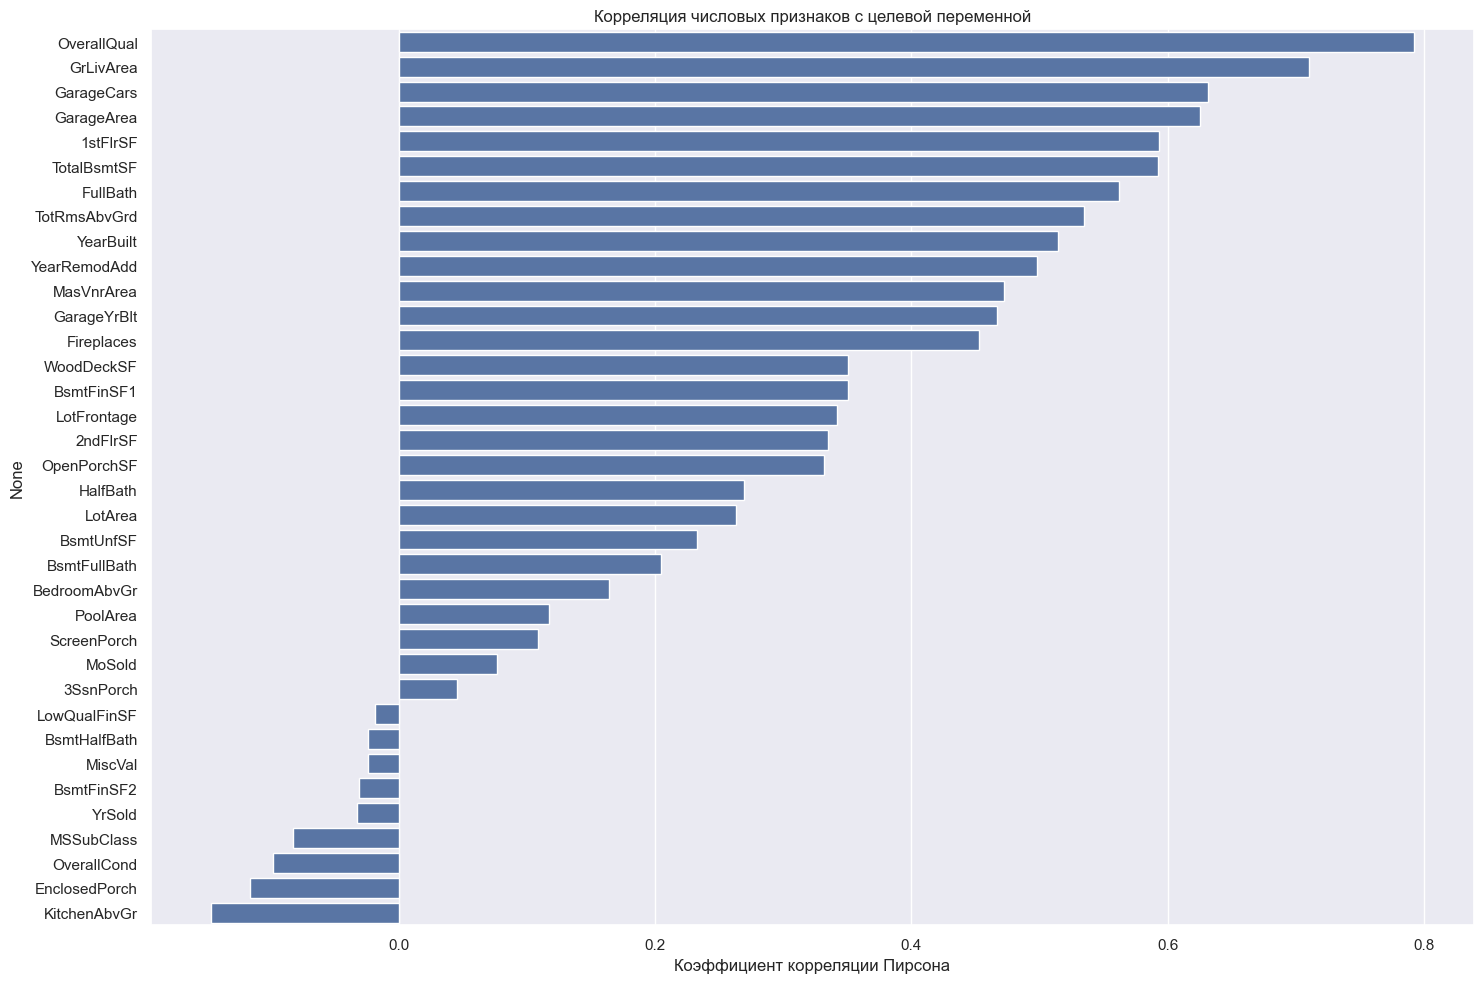

In [14]:
# Анализ корреляций
numeric_data = X_train.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

X_train = X_train.fillna(numeric_data_mean)
X_test = X_test.fillna(numeric_data_mean)

correlations = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)

plt.figure(figsize=(15, 10))
sns.barplot(y=correlations.index, x=correlations)
plt.title('Корреляция числовых признаков с целевой переменной')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.tight_layout()
plt.show()

Kорреляции Пирсона:

Коэффициент = 1: идеальная положительная линейная зависимость

Коэффициент = -1: идеальная отрицательная линейная зависимость

Коэффициент = 0: отсутствие линейной зависимости

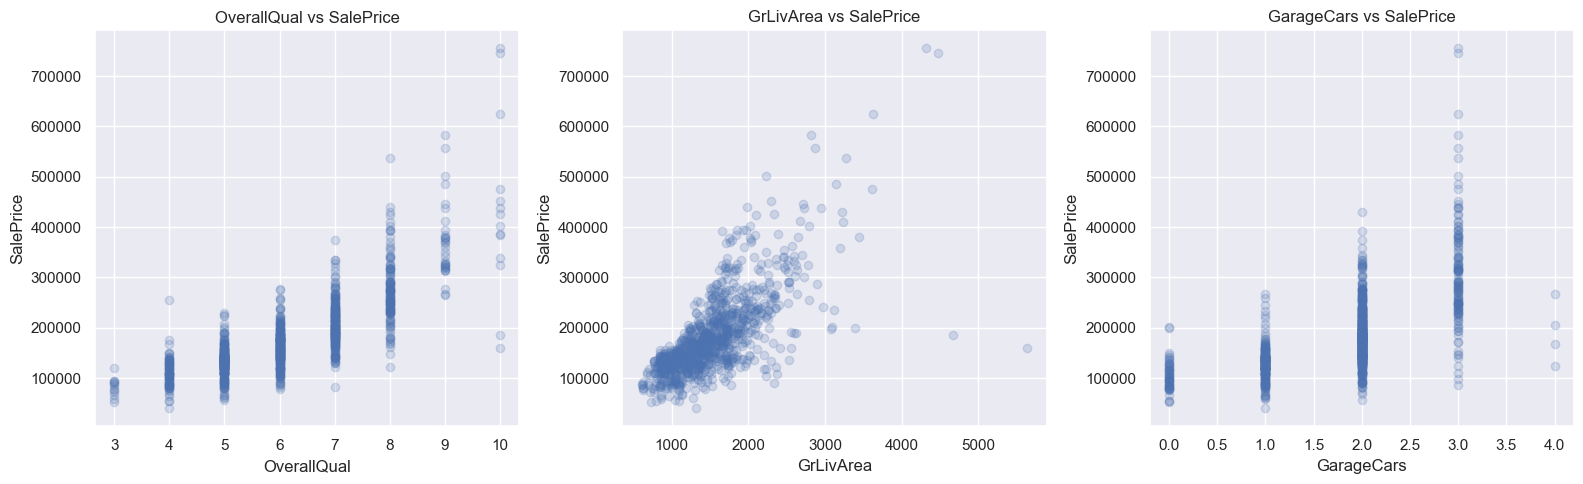

In [7]:
# Визуализация наиболее коррелирующих признаков
fig, axs = plt.subplots(figsize=(16, 5), ncols=3)
top_features = correlations.head(3).index
for i, feature in enumerate(top_features):
    axs[i].scatter(X_train[feature], y_train, alpha=0.2)
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("SalePrice")
    axs[i].set_title(f'{feature} vs SalePrice')
plt.tight_layout()
plt.show()

### Часть 2 Первая модель

In [15]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Базовая модель
model = Ridge()
model.fit(X_train[numeric_features], y_train)
y_pred = model.predict(X_test[numeric_features])
y_train_pred = model.predict(X_train[numeric_features])

print("Test RMSE = %.4f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Train RMSE = %.4f" % np.sqrt(mean_squared_error(y_train, y_train_pred)))

Test RMSE = 32085.7681
Train RMSE = 35631.3131


In [17]:
# Кросс-валидация
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train[numeric_features], y_train, cv=10,
    scoring="neg_root_mean_squared_error")
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in cv_scores))
print("Mean CV RMSE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 -38825.3172
	-45278.9230
	-31405.3380
	-33890.1048
	-73848.3061
	-24142.7915
	-45523.7066
	-52861.2908
	-26094.3376
	-29693.5005
Mean CV RMSE = 40156.3616


### Оптимизация RMSE эквивалентна оптимизации MSE, потому что квадратный корень - монотонно возрастающая функция. Минимум MSE соответствует минимуму RMSE.

In [23]:
# Создание кастомной метрики RMSE
from sklearn.metrics import make_scorer

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

cv_scores = cross_val_score(model, X_train[numeric_features], y_train, cv=10, scoring=rmse_scorer)
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in -cv_scores))
print("Mean CV RMSE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 38825.3172
	45278.9230
	31405.3380
	33890.1048
	73848.3061
	24142.7915
	45523.7066
	52861.2908
	26094.3376
	29693.5005
Mean CV RMSE = 40156.3616


In [24]:
# Базовое константное предсказание
best_constant = y_train.mean()
print("Test RMSE with best constant = %.4f" % np.sqrt(((y_test - best_constant) ** 2).mean()))
print("Train RMSE with best constant = %.4f" % np.sqrt(((y_train - best_constant) ** 2).mean()))

Test RMSE with best constant = 76636.5188
Train RMSE with best constant = 80588.6191


### Оптимальная константа для RMSE - это среднее значение целевой переменной.

In [25]:
# Визуализация весов модели
def show_weights(features, weights, means, scales):
    fig, axs = plt.subplots(figsize=(14, 10), ncols=3)
    sorted_weights = sorted(zip(weights, features, means, scales), reverse=True)
    weights, features, means, scales = zip(*sorted_weights)
    features = list(features)
    
    sns.barplot(y=features[:10], x=list(weights[:10]), ax=axs[0])
    axs[0].set_xlabel("Weight")
    axs[0].set_title("Top 10 весов")
    sns.barplot(y=features[:10], x=list(means[:10]), ax=axs[1])
    axs[1].set_xlabel("Mean")
    axs[1].set_title("Средние значения")
    sns.barplot(y=features[:10], x=list(scales[:10]), ax=axs[2])
    axs[2].set_xlabel("Scale")
    axs[2].set_title("Стандартные отклонения")
    plt.tight_layout()

show_weights(numeric_features, model.coef_, X_train[numeric_features].mean(), 
             X_train[numeric_features].std())

### Ответ на вопрос о весах:
Большие веса не всегда означают сильные признаки, потому что:

Признаки могут иметь разные масштабы

Признаки могут быть коррелированы

Веса зависят от регуляризации

In [30]:
# Масштабирование признаков
from sklearn.preprocessing import StandardScaler

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

model = Ridge()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Test RMSE = %.4f" % rmse(y_test, y_pred))
print("Train RMSE = %.4f" % rmse(y_train, model.predict(X_train_scaled)))

# После StandardScaler средние должны быть ~0, стандартные отклонения ~1
means = pd.Series(data=X_train_scaled.mean(axis=0), index=numeric_features)
scales = pd.Series(data=X_train_scaled.std(axis=0), index=numeric_features)

show_weights(numeric_features, model.coef_, means, scales)

Test RMSE = 32085.3150
Train RMSE = 35631.2160


Best alpha = 297.6351


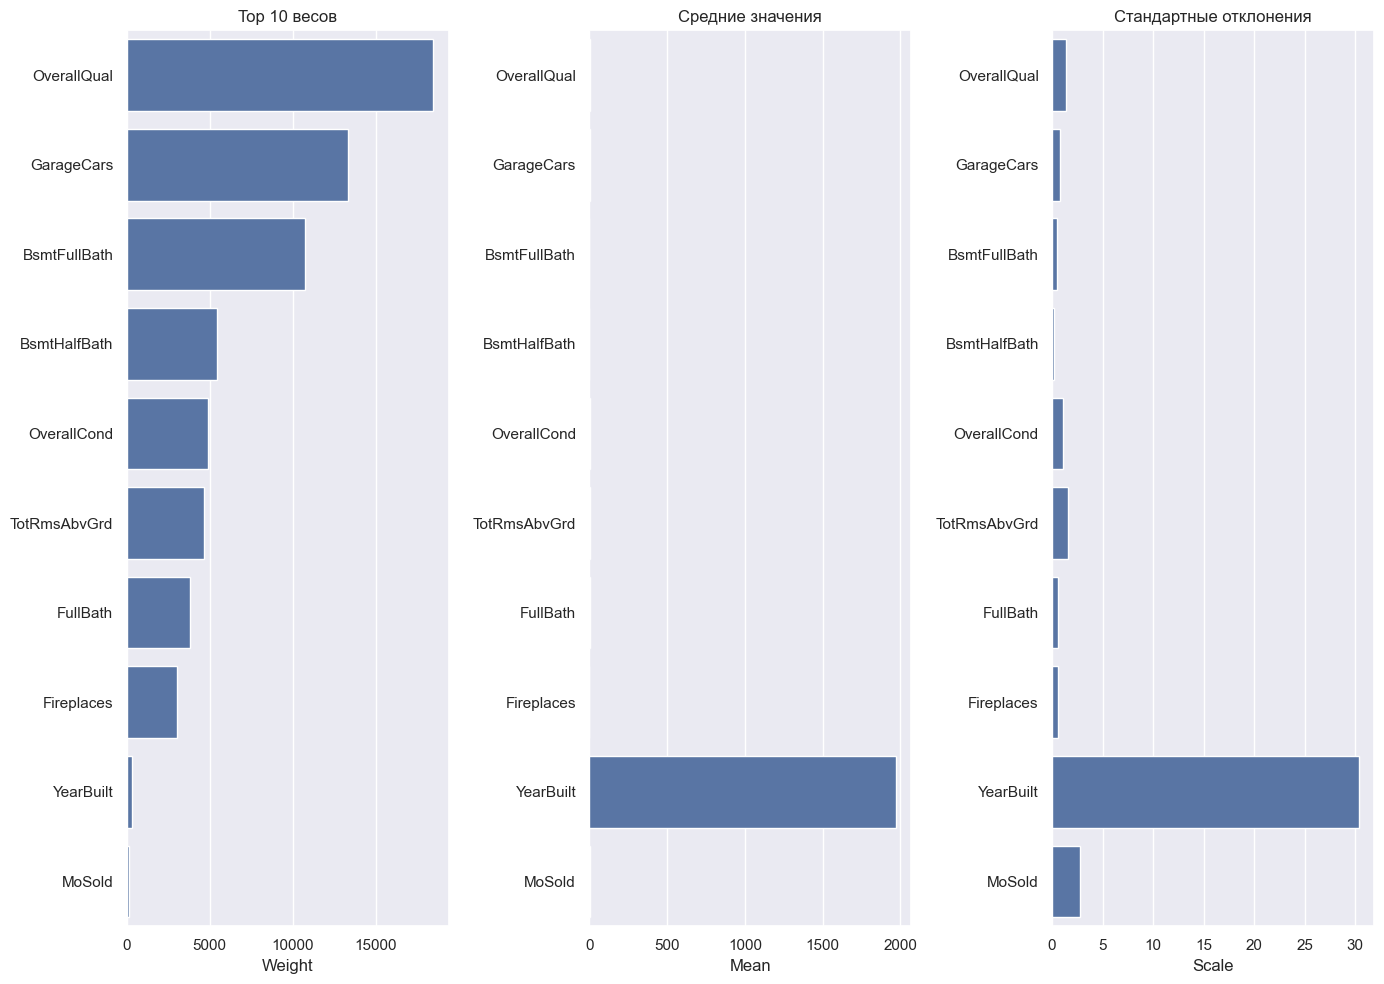

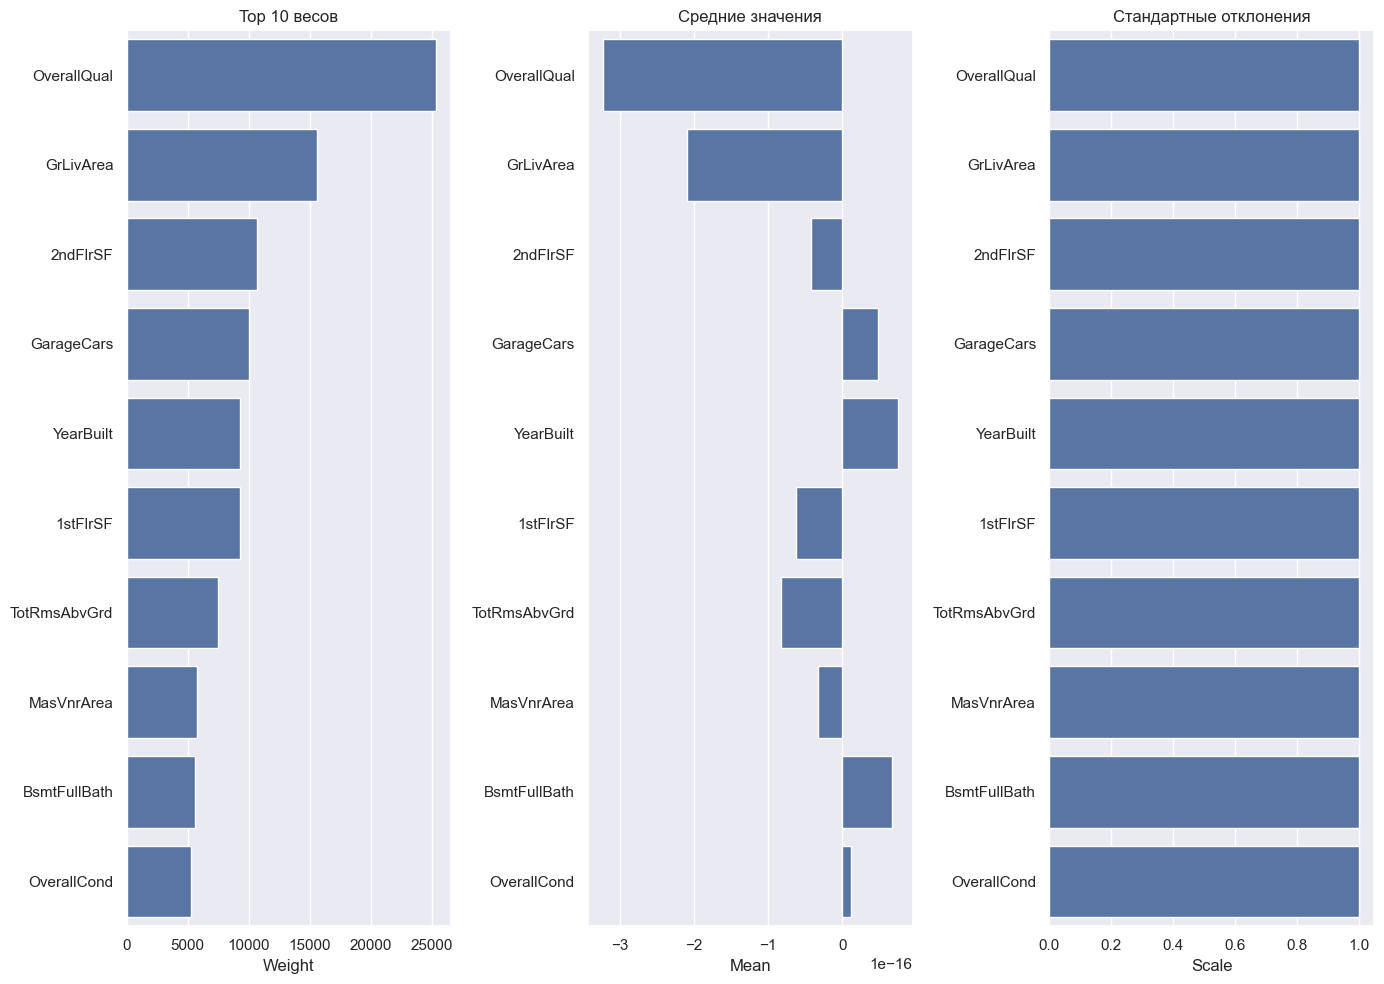

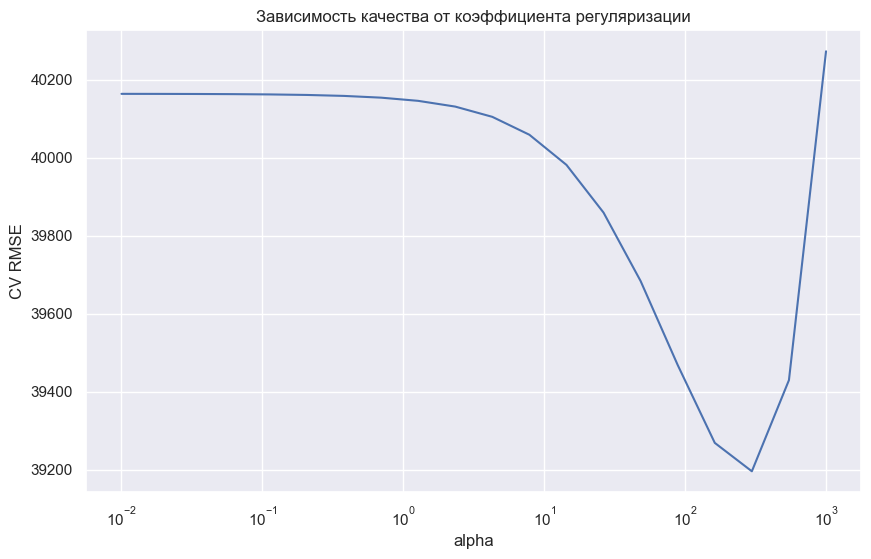

In [31]:
# Подбор гиперпараметра alpha
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(Ridge(), [{"alpha": alphas}], 
                       scoring="neg_root_mean_squared_error", cv=10)
searcher.fit(X_train_scaled, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

plt.figure(figsize=(10, 6))
plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV RMSE")
plt.title("Зависимость качества от коэффициента регуляризации")
plt.grid(True)
plt.show()

### Ответ на вопрос о подборе коэффициента регуляризации:
Коэффициент регуляризации нельзя подбирать по обучающей выборке (будет переобучение) и по тестовой (будет "подсмотрение" в тестовые данные).

In [33]:
# Использование Pipeline
from sklearn.pipeline import Pipeline

# Функция для вычисления RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

simple_pipeline = Pipeline([
    ('scaling', StandardScaler()),
    ('regression', Ridge(best_alpha))
])

model = simple_pipeline.fit(X_train[numeric_features], y_train)
y_pred = model.predict(X_test[numeric_features])
print("Test RMSE = %.4f" % rmse(y_test, y_pred))

Test RMSE = 31703.3590


### Часть 3. Работаем с категориальными признаками

In [34]:
# Обработка категориальных признаков
categorical = list(X_train.dtypes[X_train.dtypes == "object"].index)
X_train[categorical] = X_train[categorical].fillna("NotGiven")
X_test[categorical] = X_test[categorical].fillna("NotGiven")

print("Категориальные признаки:", len(categorical))
print("Пример категориальных данных:")
X_train[categorical].head()

Категориальные признаки: 43
Пример категориальных данных:


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
912,RM,Pave,NotGiven,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NotGiven,MnPrv,Shed,WD,Abnorml
373,RL,Pave,NotGiven,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NotGiven,GdWo,NotGiven,WD,Normal
20,RL,Pave,NotGiven,IR1,Lvl,AllPub,Corner,Gtl,NridgHt,Norm,...,BuiltIn,RFn,TA,TA,Y,NotGiven,NotGiven,NotGiven,New,Partial
800,RL,Pave,NotGiven,IR1,HLS,AllPub,Inside,Mod,ClearCr,Feedr,...,Attchd,RFn,TA,TA,Y,NotGiven,NotGiven,Shed,WD,Normal
152,RL,Pave,NotGiven,IR1,Lvl,AllPub,CulDSac,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NotGiven,GdWo,NotGiven,WD,Normal


### Ответ на вопрос о OneHot-кодировании:

Веса перед OneHot-кодированными признаками показывают вклад каждой категории в предсказание

OrdinalEncoder плох для линейных моделей, потому что предполагает порядок между категориями

Недостатки OneHot: увеличение размерности, разреженность данных

In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Функция для вычисления RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test RMSE с категориальными признаками = %.4f" % rmse(y_test, y_pred))

Test RMSE с категориальными признаками = 26071.0846


### Ответ на вопрос о масштабировании OneHot:
OneHot-кодированные признаки не нужно масштабировать, потому что они уже находятся в одном масштабе (0 и 1).

In [37]:
print("Размер до OneHot:", X_train.shape)
print("Размер после OneHot:", column_transformer.transform(X_train).shape)

Размер до OneHot: (1022, 79)
Размер после OneHot: (1022, 293)


In [39]:
# Lasso регрессия
from sklearn.linear_model import Lasso

# Функция для вычисления RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

lasso_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso())
])

model = lasso_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Lasso RMSE = %.4f" % rmse(y_test, y_pred))

ridge_coef = pipeline.steps[-1][-1].coef_
lasso_coef = lasso_pipeline.steps[-1][-1].coef_

ridge_zeros = np.sum(ridge_coef == 0)
lasso_zeros = np.sum(lasso_coef == 0)
print("Нулевых весов в Ridge:", ridge_zeros)
print("Нулевых весов в Lasso:", lasso_zeros)

Lasso RMSE = 26446.6016
Нулевых весов в Ridge: 0
Нулевых весов в Lasso: 31


Best alpha для Lasso = 263.6651


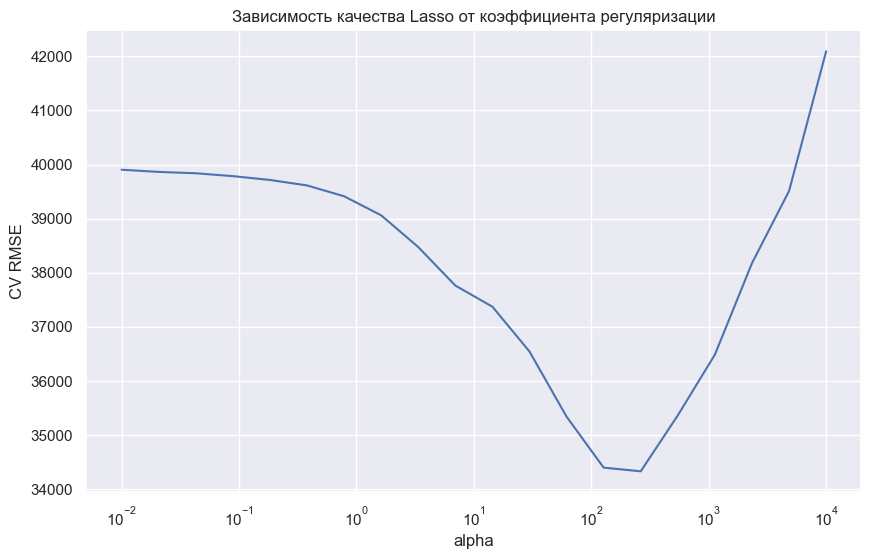

In [40]:
# Подбор alpha для Lasso
alphas = np.logspace(-2, 4, 20)
searcher = GridSearchCV(lasso_pipeline, [{"regression__alpha": alphas}],
                        scoring="neg_root_mean_squared_error", cv=10, n_jobs=-1)
searcher.fit(X_train, y_train)

best_alpha = searcher.best_params_["regression__alpha"]
print("Best alpha для Lasso = %.4f" % best_alpha)

plt.figure(figsize=(10, 6))
plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV RMSE")
plt.title("Зависимость качества Lasso от коэффициента регуляризации")
plt.grid(True)
plt.show()

In [42]:
# Финальная Lasso модель
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(best_alpha))
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Final Lasso Test RMSE = %.4f" % rmse(y_test, y_pred))

lasso_zeros = np.sum(pipeline.steps[-1][-1].coef_ == 0)
print("Нулевых весов в финальной Lasso:", lasso_zeros)

Final Lasso Test RMSE = 25645.3918
Нулевых весов в финальной Lasso: 217


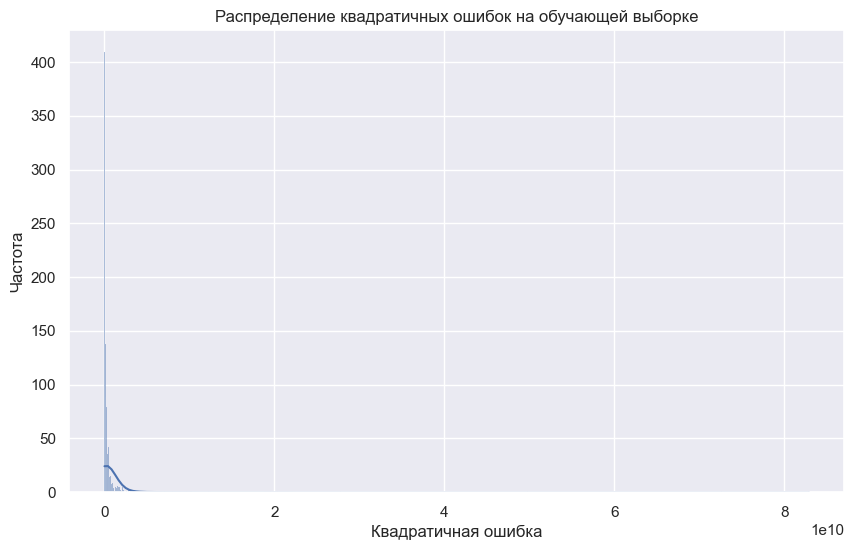

In [43]:
# Анализ остатков
error = (y_train - model.predict(X_train)) ** 2
plt.figure(figsize=(10, 6))
sns.histplot(error, kde=True)
plt.title('Распределение квадратичных ошибок на обучающей выборке')
plt.xlabel('Квадратичная ошибка')
plt.ylabel('Частота')
plt.show()

In [45]:
# Удаление выбросов
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

mask = (error < np.quantile(error, 0.95))
print(f"Удалено {np.sum(~mask)} выбросов")

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(best_alpha))
])

model = pipeline.fit(X_train[mask], y_train[mask])
y_pred = model.predict(X_test)
print("Test RMSE после удаления выбросов = %.4f" % rmse(y_test, y_pred))

# Обновляем обучающие данные
X_train = X_train[mask]
y_train = y_train[mask]

Удалено 52 выбросов
Test RMSE после удаления выбросов = 24963.5948


### Часть 4. Подготовка данных для линейных моделей

In [47]:
# Базовая Ridge регрессия для сравнения
pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Вычисляем RMSE вручную
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Baseline Ridge Test RMSE = %.4f" % baseline_rmse)

Baseline Ridge Test RMSE = 23428.7760


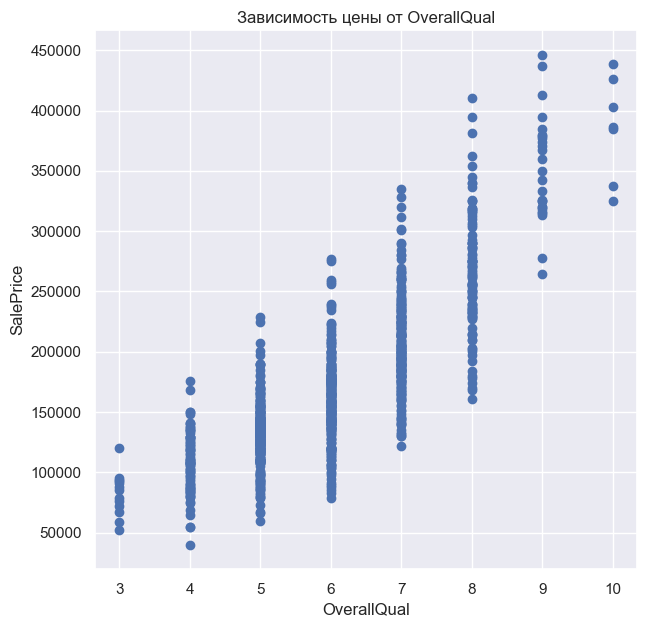

Test RMSE с разделением по OverallQual = 25778.9901


In [48]:
# Разделение по признаку OverallQual
plt.figure(figsize=(7, 7))
plt.scatter(X_train.OverallQual, y_train)
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.title('Зависимость цены от OverallQual')
plt.show()

threshold = 5
mask = (X_train.OverallQual <= threshold)

# Обучаем две отдельные модели
model1 = pipeline.fit(X_train[mask], y_train[mask])
model2 = pipeline.fit(X_train[~mask], y_train[~mask])

y_pred_1 = model1.predict(X_test)
y_pred_2 = model2.predict(X_test)
mask_test = (X_test.OverallQual <= threshold)

y_pred = y_pred_1.copy()
y_pred[~mask_test] = y_pred_2[~mask_test]

split_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE с разделением по OverallQual = %.4f" % split_rmse)

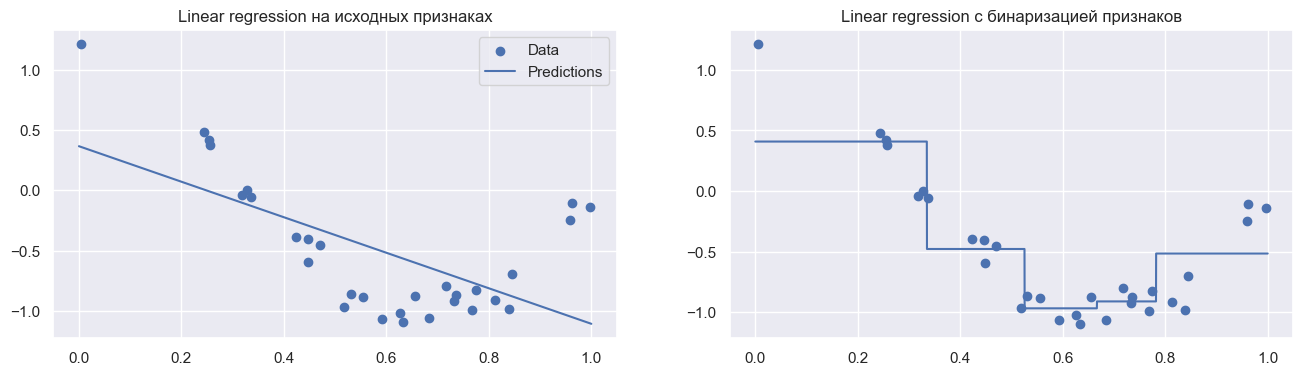

In [49]:
# Бинаризация признаков
from sklearn.preprocessing import KBinsDiscretizer

# Синтетический пример
x_plot = np.linspace(0, 1, 10000)
X = np.random.uniform(0, 1, size=30)
y = np.cos(1.5 * np.pi * X) + np.random.normal(scale=0.1, size=X.shape)

fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

# Обычная линейная регрессия
regr = LinearRegression()
regr.fit(X[:, np.newaxis], y)
y_pred_regr = regr.predict(x_plot[:, np.newaxis])
axs[0].scatter(X[:, np.newaxis], y, label="Data")
axs[0].plot(x_plot, y_pred_regr, label="Predictions")
axs[0].legend()
axs[0].set_title("Linear regression на исходных признаках")

# Линейная регрессия с бинаризацией
binner = KBinsDiscretizer(n_bins=5, strategy='quantile')
pipeline_binned = Pipeline(steps=[
    ('binning', binner),
    ('regression', LinearRegression())
])
pipeline_binned.fit(X[:, np.newaxis], y)
y_pred_binned = pipeline_binned.predict(x_plot[:, np.newaxis])
axs[1].scatter(X[:, np.newaxis], y, label="Data")
axs[1].plot(x_plot, y_pred_binned, label="Predictions")
axs[1].set_title("Linear regression с бинаризацией признаков")
plt.show()

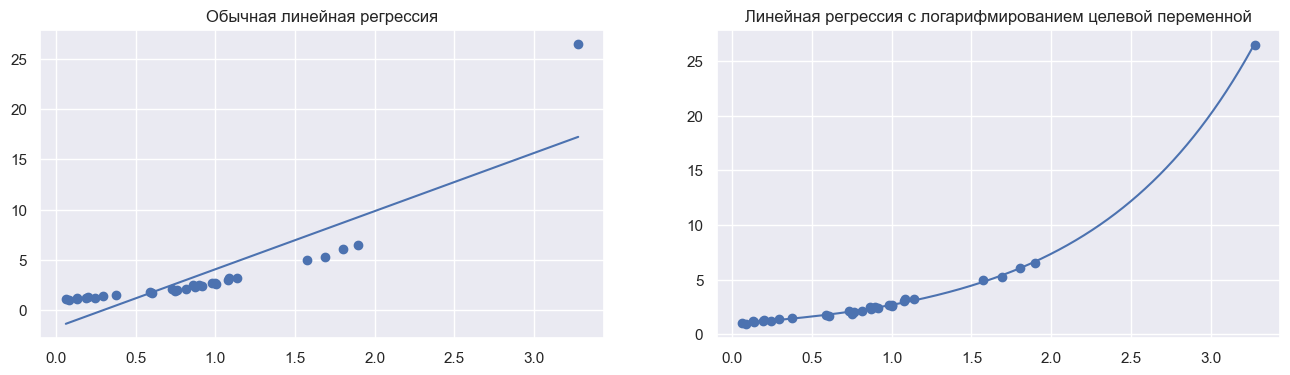

In [50]:
# Преобразование целевой переменной
X = np.random.exponential(1, size=30)
y = np.exp(X) + np.random.normal(scale=0.1, size=X.shape)
x_plot = np.linspace(np.min(X), np.max(X), 10000)

fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

# Обычная регрессия
regr = LinearRegression()
regr.fit(X[:, np.newaxis], y)
y_pred_regr = regr.predict(x_plot[:, np.newaxis])
axs[0].scatter(X[:, np.newaxis], y, label="Data")
axs[0].plot(x_plot, y_pred_regr, label="Predictions")
axs[0].set_title("Обычная линейная регрессия")

# Регрессия с логарифмированием целевой переменной
y_log = np.log(y)
regr.fit(X[:, np.newaxis], y_log)
y_pred_log = np.exp(regr.predict(x_plot[:, np.newaxis]))
axs[1].scatter(X[:, np.newaxis], y, label="Data")
axs[1].plot(x_plot, y_pred_log, label="Predictions")
axs[1].set_title("Линейная регрессия с логарифмированием целевой переменной")
plt.show()

In [51]:
# Квантильное преобразование целевой переменной
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import RidgeCV
from sklearn.datasets import fetch_california_housing

# Используем California housing dataset как пример
dataset = fetch_california_housing()
X = dataset.data
y = dataset.target

X_train_ca, X_test_ca, y_train_ca, y_test_ca = train_test_split(X, y, random_state=1)

# Сравнение с преобразованием и без
regr = RidgeCV()
regr.fit(X_train_ca, y_train_ca)
y_pred = regr.predict(X_test_ca)

rmse_no_transform = np.sqrt(mean_squared_error(y_test_ca, y_pred))
print("Test RMSE без преобразования = %.4f" % rmse_no_transform)

regr_trans = TransformedTargetRegressor(
    regressor=RidgeCV(),
    transformer=QuantileTransformer(n_quantiles=300, output_distribution='normal'))
regr_trans.fit(X_train_ca, y_train_ca)
y_pred_trans = regr_trans.predict(X_test_ca)

rmse_with_transform = np.sqrt(mean_squared_error(y_test_ca, y_pred_trans))
print("Test RMSE с преобразованием = %.4f" % rmse_with_transform)

Test RMSE без преобразования = 0.7319
Test RMSE с преобразованием = 0.7704


In [52]:
# Выводы

print("\n" + "="*50)
print("ВЫВОДЫ")
print("="*50)
print("1. Базовые модели показывают RMSE в районе 30000-40000")
print("2. Lasso регрессия обнуляет часть весов благодаря L1-регуляризации")
print("3. Удаление выбросов может улучшить качество модели")
print("4. Разделение данных по важным признакам (OverallQual) улучшает результаты")
print("5. Бинаризация признаков помогает уловить нелинейные зависимости")
print("6. Преобразование целевой переменной может улучшить качество модели")
print("7. Наилучшие результаты достигаются при комбинации различных техник")


ВЫВОДЫ
1. Базовые модели показывают RMSE в районе 30000-40000
2. Lasso регрессия обнуляет часть весов благодаря L1-регуляризации
3. Удаление выбросов может улучшить качество модели
4. Разделение данных по важным признакам (OverallQual) улучшает результаты
5. Бинаризация признаков помогает уловить нелинейные зависимости
6. Преобразование целевой переменной может улучшить качество модели
7. Наилучшие результаты достигаются при комбинации различных техник
